**Description**

This notebook is designed to process and prepare Balancer V1 Liquidity Bootstrapping Pool (LBP) data from Dune for machine learning analysis. Its main purposes are:

1. **Advanced Metric Calculation**: Computes sophisticated LBP performance metrics including:
   - **Weight Slope**: Rate of token weight change during the LBP duration
   - **Theoretical Price Curve**: Simulates the expected price decay based on weight adjustments
   - **Buy Pressure**: Measures if actual trading prices exceeded theoretical curve (demand signal)
   - **Max Drawdown**: Calculates largest negative deviation from the theoretical price
   - **Price Efficiency**: Compares final LBP price vs. market price 24 hours post-launch

2. **Data Cleaning & Imputation**: 
   - Handles missing values intelligently (e.g., fills missing start weights with 0.90 heuristic for V1 LBPs)
   - Creates "dead pool" flags to distinguish missing data from actual failures
   - Fills missing efficiency and price metrics with 0 to represent pool failures

3. **Multi-CSV Integration**: Merges multiple V1 CSV files:
   - General metrics (duration, weights, swaps)
   - Entropy and bot volume percentages
   - Initial token price data

4. **Success Label Generation**: Creates binary classification targets based on thresholds:
   - **Price Discovery Success**: Efficiency > 0.75
   - **Activity Success**: Entropy > 0.70
   - **Non-Bot Success**: Bot volume < 45%
   - **Final Success**: Meets all three criteria (AND logic)

5. **Exploratory Analysis**: Generates correlation heatmaps to identify which features are most predictive of successful LBPs.

6. **Output**: Saves the finalized, labeled dataset as `FINAL_LBPs_BalancerV1.csv`, ready for model training with balanced target variables.

# Imports

In [7]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Formatting

In [12]:
expected_columns = [
  'pool_id', 
  'launch_date',
  'duration_h',
  'start_weight_proj',
  'end_weight_proj',
  'weight_slope',
  'initial_fdv_usd',
  'total_swaps',
  'unique_users',
  'activity_entropy',
  'swaps_per_hour',
  'peak_activity_time',
  'bot_volume_pct',
  'price_efficiency',
  'max_drawdown',
  'buy_pressure_avg',
  'price_found_success',
  'consistent_activity_success',
  'not_bot_success',
  'final_success'
]
print(len(expected_columns))

20


In [3]:
def calculate_lbp_metrics(summary_file='lbp_summary.csv', trades_file='trades.csv'):
    # 1. Load Data
    df = pd.read_csv(summary_file)
    
    # Check if trades file exists (required for complex metrics)
    try:
        trades = pd.read_csv(trades_file)
        trades['block_time'] = pd.to_datetime(trades['block_time'])
        has_trades = True
    except FileNotFoundError:
        print("Warning: 'trades.csv' not found. Max Drawdown & Buy Pressure will be NaN.")
        has_trades = False

    # 2. Fill Static Columns (Heuristics for V1)
    # V1 LBPs often started at 90% or 95% weight. 
    # Since SQL returned NULL, we assume 0.90 (90%) if missing.
    df['start_weight_proj'] = df['start_weight_proj'].fillna(0.90) 
    
    # 3. Calculate Weight Slope
    # Formula: (start - end) / duration
    df['weight_slope'] = (df['start_weight_proj'] - df['end_weight_proj']) / df['duration_h']

    # 4. Complex Metrics Loop
    if has_trades:
        drawdowns = []
        buy_pressures = []
        efficiencies = []

        for index, row in df.iterrows():
            pool_id = row['pool_id']
            # Filter trades for this pool
            pool_trades = trades[trades['pool_id'] == pool_id].sort_values('block_time')
            
            if pool_trades.empty:
                drawdowns.append(np.nan)
                buy_pressures.append(np.nan)
                efficiencies.append(np.nan)
                continue

            # --- A. Theoretical Price Curve Simulation ---
            # (Simplified Linear Weight Decay Model)
            # Price_t = (TokenBalance / CollateralBalance) * (CollateralWeight_t / TokenWeight_t)
            # Since we lack balance data in CSV, we approximate using the theoretical drop.
            # Theory: Price drops purely due to weight change.
            
            duration_seconds = row['duration_h'] * 3600
            start_time = pd.to_datetime(row['launch_date'])
            end_time = start_time + pd.Timedelta(hours=row['duration_h'])
            
            # Calculate time progress (0 to 1) for each trade
            pool_trades['time_elapsed'] = (pool_trades['block_time'] - start_time).dt.total_seconds()
            pool_trades['progress'] = pool_trades['time_elapsed'] / duration_seconds
            pool_trades = pool_trades[(pool_trades['progress'] >= 0) & (pool_trades['progress'] <= 1)]

            # Interpolate Weights
            # start_w -> end_w
            w_start = row['start_weight_proj']
            w_end = row['end_weight_proj']
            
            # Current Weight at time t
            pool_trades['curr_weight'] = w_start - (pool_trades['progress'] * (w_start - w_end))
            
            # Theoretical Price Decay Factor (relative to start price)
            # Assuming constant balances (ceteris paribus), Price ~ Weight / (1-Weight)
            # This is a proxy. For exact values, you need balance history.
            initial_price = pool_trades.iloc[0]['amount_usd'] / pool_trades.iloc[0]['token_bought_amount'] if pool_trades.iloc[0]['token_bought_amount'] > 0 else 1
            
            # Theoretical Price t = Initial Price * (Weight_Factor_t / Weight_Factor_start)
            # Weight Factor = w / (1-w)
            wf_start = w_start / (1 - w_start)
            pool_trades['weight_factor'] = pool_trades['curr_weight'] / (1 - pool_trades['curr_weight'])
            pool_trades['theo_price'] = initial_price * (pool_trades['weight_factor'] / wf_start)
            
            # Actual Price
            pool_trades['actual_price'] = pool_trades['amount_usd'] / pool_trades['token_bought_amount']
            
            # --- B. Calculate Metrics ---
            
            # Buy Pressure: Avg(Actual / Theoretical)
            # > 1 means buying pushed price above the curve. < 1 means selling dominates.
            avg_bp = (pool_trades['actual_price'] / pool_trades['theo_price']).mean()
            buy_pressures.append(avg_bp)

            # Max Drawdown: Max % drop from the Theoretical Curve (or peak)
            # Here: Largest negative deviation from Theoretical Price
            # (Actual - Theo) / Theo
            deviations = (pool_trades['actual_price'] - pool_trades['theo_price']) / pool_trades['theo_price']
            max_dd = deviations.min() # Looking for the deepest negative value
            drawdowns.append(max_dd)

            # Price Efficiency
            # 1 - (abs(Last_LBP_Price - Post_Price) / Last_LBP_Price)
            last_trade = pool_trades.iloc[-1]
            last_price = last_trade['actual_price']
            post_price = row['market_price_24h_post']
            
            if pd.notna(post_price) and last_price > 0:
                eff = 1 - (abs(last_price - post_price) / last_price)
            else:
                eff = np.nan
            efficiencies.append(eff)

        # Assign back to DF
        df['max_drawdown'] = drawdowns
        df['buy_pressure_avg'] = buy_pressures
        df['price_efficiency'] = efficiencies

    # 5. Save Completed CSV
    df.to_csv('lbp_completed.csv', index=False)
    print("Processing complete. Saved to 'lbp_completed.csv'.")
    return df

# Usage
df_final = calculate_lbp_metrics('../media/v1/LBPs_BalancerV1_general_metrics.csv','../media/v1/dev_LBPs_BalancerV1_timeline_trades.csv')

Processing complete. Saved to 'lbp_completed.csv'.


In [4]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                96 non-null     object 
 1   launch_date            96 non-null     object 
 2   duration_h             96 non-null     float64
 3   start_weight_proj      96 non-null     float64
 4   end_weight_proj        96 non-null     float64
 5   weight_slope           96 non-null     float64
 6   total_swaps            96 non-null     int64  
 7   unique_users           96 non-null     int64  
 8   swaps_per_hour         96 non-null     float64
 9   peak_activity_time     96 non-null     float64
 10  price_efficiency       55 non-null     float64
 11  market_price_24h_post  68 non-null     float64
 12  max_drawdown           65 non-null     float64
 13  buy_pressure_avg       65 non-null     float64
dtypes: float64(10), int64(2), object(2)
memory usage: 10.6+ KB


In [6]:
# 1. Create a binary flag for "Dead/Inactive" pools
# This helps Tree-based models (XGBoost, Random Forest) distinguish "Real 0" from "Missing 0"
df_final['is_dead_pool'] = df_final['market_price_24h_post'].isna().astype(int)

# 2. Fill missing values with 0 to represent failure
cols_to_fix = ['price_efficiency', 'market_price_24h_post', 'max_drawdown', 'buy_pressure_avg']
df_final[cols_to_fix] = df_final[cols_to_fix].fillna(0)

# Now you have 96 rows ready for training
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                96 non-null     object 
 1   launch_date            96 non-null     object 
 2   duration_h             96 non-null     float64
 3   start_weight_proj      96 non-null     float64
 4   end_weight_proj        96 non-null     float64
 5   weight_slope           96 non-null     float64
 6   total_swaps            96 non-null     int64  
 7   unique_users           96 non-null     int64  
 8   swaps_per_hour         96 non-null     float64
 9   peak_activity_time     96 non-null     float64
 10  price_efficiency       96 non-null     float64
 11  market_price_24h_post  96 non-null     float64
 12  max_drawdown           96 non-null     float64
 13  buy_pressure_avg       96 non-null     float64
 14  is_dead_pool           96 non-null     int64  
dtypes: float

In [7]:
df_final.to_csv('dev_lbp_final_for_modeling.csv', index=False)

df_final.head()

,pool_id,launch_date,duration_h,start_weight_proj,end_weight_proj,weight_slope,total_swaps,unique_users,swaps_per_hour,peak_activity_time,price_efficiency,market_price_24h_post,max_drawdown,buy_pressure_avg,is_dead_pool
0,0x5507293eeb2d771bda8ba036a121e5d2ed22cf88,2023-01-11 10:18:47.000 UTC,34.146667,0.9,2.392344,-0.043704,0,0,0.000000,0.000000,0.000000,0.078841,0.000000,0.000000,0
1,0x19a82bab298c547f911572cf960401880fbb44ae,2022-07-30 18:11:22.000 UTC,0.041111,0.9,1.000000,-2.432432,0,0,0.000000,0.000000,0.000000,23236.908771,0.000000,0.000000,0
2,0xfc3cca33112b1861c165badc997c970a0a447d5a,2021-09-28 13:02:07.000 UTC,74.664444,0.9,17.500000,-0.222328,43,29,0.575910,0.697934,0.487082,4.289626,-6.363701,4.288153,0
3,0x53f863e835722533c5832944da75a69f78f0018e,2021-09-27 12:59:30.000 UTC,23.631111,0.9,11.250000,-0.437982,1234,753,52.219297,0.640087,0.249231,0.249408,-51.849697,-17.006686,0
4,0x3029c3763d4b61b255b5eea5a506cb2f080487a7,2021-09-23 10:06:06.000 UTC,49.206389,0.9,3.009877,-0.042878,5,5,0.101613,0.516092,0.999249,1.000318,-15142.226710,-3031.371727,0


# Merge CSVs

In [8]:
dfs = {}

folder_path = '../media/v1'

dfs['general_metrics.csv'] = pd.read_csv(os.path.join(folder_path, 'dev_lbp_final_for_modeling.csv'))
dfs['entropy_bot_initial_price'] = pd.read_csv(os.path.join(folder_path, 'LBPs_BalancerV1_entropy_bot_initial_price.csv'))

dfs.keys()

dict_keys(['general_metrics.csv', 'entropy_bot_initial_price'])

In [9]:
# Merge all CSVs on 'pool_id'

df_final = dfs['general_metrics.csv']
for key, df in dfs.items():
    if key == 'general_metrics.csv':
        continue
    df_final = pd.merge(df_final, df, on='pool_id', how='inner')

print("Merged DataFrame Info:", df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                96 non-null     object 
 1   launch_date            96 non-null     object 
 2   duration_h             96 non-null     float64
 3   start_weight_proj      96 non-null     float64
 4   end_weight_proj        96 non-null     float64
 5   weight_slope           96 non-null     float64
 6   total_swaps            96 non-null     int64  
 7   unique_users           96 non-null     int64  
 8   swaps_per_hour         96 non-null     float64
 9   peak_activity_time     96 non-null     float64
 10  price_efficiency       96 non-null     float64
 11  market_price_24h_post  96 non-null     float64
 12  max_drawdown           96 non-null     float64
 13  buy_pressure_avg       96 non-null     float64
 14  is_dead_pool           96 non-null     int64  
 15  initial_

In [10]:
# 1. Inspect the relationship between missing Price and Total Swaps
missing_price_rows = df_final[df_final['initial_token_price'].isna()]
print(f"Rows with missing price: {len(missing_price_rows)}")
print(f"Of those, how many had 0 swaps? {len(missing_price_rows[missing_price_rows['total_swaps'] == 0])}")

# 2. FILL STRATEGY: 
# If swaps == 0, the price is logically 0.
# If swaps > 0 but price is missing (edge case), 0 is still safer than Mean 
# because it likely indicates an obscure/broken market pairing.

df_final['initial_token_price'] = df_final['initial_token_price'].fillna(0)

# 3. Final Check
print("\nFinal Non-Null Counts:")
print(df_final.info())

Rows with missing price: 17
Of those, how many had 0 swaps? 13

Final Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                96 non-null     object 
 1   launch_date            96 non-null     object 
 2   duration_h             96 non-null     float64
 3   start_weight_proj      96 non-null     float64
 4   end_weight_proj        96 non-null     float64
 5   weight_slope           96 non-null     float64
 6   total_swaps            96 non-null     int64  
 7   unique_users           96 non-null     int64  
 8   swaps_per_hour         96 non-null     float64
 9   peak_activity_time     96 non-null     float64
 10  price_efficiency       96 non-null     float64
 11  market_price_24h_post  96 non-null     float64
 12  max_drawdown           96 non-null     float64
 13  buy_pressure_avg       96

# Create success columns

In [11]:
price_efficiency_th = 0.75
activity_entropy_th = 0.7
bot_volume_pct_th = 0.45

def add_success_labels(df):
    df = df.copy()
    """
    Adds binary classification labels (0/1) based on success criteria.
    """
    # 1. Price Discovery Success
    # Logic: Success if post-launch price is within 15% of the final LBP price.
    # We infer this from 'price_efficiency'.
    # Formula: efficiency = 1 - deviation. 
    # If we want deviation < 0.15, then we need efficiency > 0.85.
    df['price_found_success'] = (df['price_efficiency'] > price_efficiency_th).astype(int)

    # 2. Consistent Activity Success
    # Logic: Entropy > 0.7 (Steady trading, not just one huge dump)
    df['consistent_activity_success'] = (df['activity_entropy'] > activity_entropy_th).astype(int)

    # 3. Not Bot Dominated
    # Logic: Bot volume < 30% (0.30)
    df['not_bot_success'] = (df['bot_volume_pct'] < bot_volume_pct_th).astype(int)

    # 4. Final Success (Goldilocks Launch)
    # Logic: AND condition (All three must be true)
    df['final_success'] = (
        (df['price_found_success'] == 1) & 
        (df['consistent_activity_success'] == 1) & 
        (df['not_bot_success'] == 1)
    ).astype(int)
    
    return df

# Usage
df_labeled = add_success_labels(df_final)
df_labeled.drop('market_price_24h_post', axis=1, inplace=True)

# Check the balance of the target class (How many 1s vs 0s)
print(df_labeled['final_success'].value_counts())
df_labeled.head()

final_success
0    84
1    12
Name: count, dtype: int64


,pool_id,launch_date,duration_h,start_weight_proj,end_weight_proj,weight_slope,total_swaps,unique_users,swaps_per_hour,peak_activity_time,...,max_drawdown,buy_pressure_avg,is_dead_pool,initial_token_price,bot_volume_pct,activity_entropy,price_found_success,consistent_activity_success,not_bot_success,final_success
0,0x5507293eeb2d771bda8ba036a121e5d2ed22cf88,2023-01-11 10:18:47.000 UTC,34.146667,0.9,2.392344,-0.043704,0,0,0.000000,0.000000,...,0.000000,0.000000,0,4.611735,0.00000,0.000000,0,0,1,0
1,0x19a82bab298c547f911572cf960401880fbb44ae,2022-07-30 18:11:22.000 UTC,0.041111,0.9,1.000000,-2.432432,0,0,0.000000,0.000000,...,0.000000,0.000000,0,28.018887,0.00000,0.000000,0,0,1,0
2,0xfc3cca33112b1861c165badc997c970a0a447d5a,2021-09-28 13:02:07.000 UTC,74.664444,0.9,17.500000,-0.222328,43,29,0.575910,0.697934,...,-6.363701,4.288153,0,4.402306,0.00000,3.864098,0,1,1,0
3,0x53f863e835722533c5832944da75a69f78f0018e,2021-09-27 12:59:30.000 UTC,23.631111,0.9,11.250000,-0.437982,1234,753,52.219297,0.640087,...,-51.849697,-17.006686,0,0.161391,0.27715,4.115569,0,1,1,0
4,0x3029c3763d4b61b255b5eea5a506cb2f080487a7,2021-09-23 10:06:06.000 UTC,49.206389,0.9,3.009877,-0.042878,5,5,0.101613,0.516092,...,-15142.226710,-3031.371727,0,0.996838,0.00000,2.321928,1,1,1,1


# Analysis

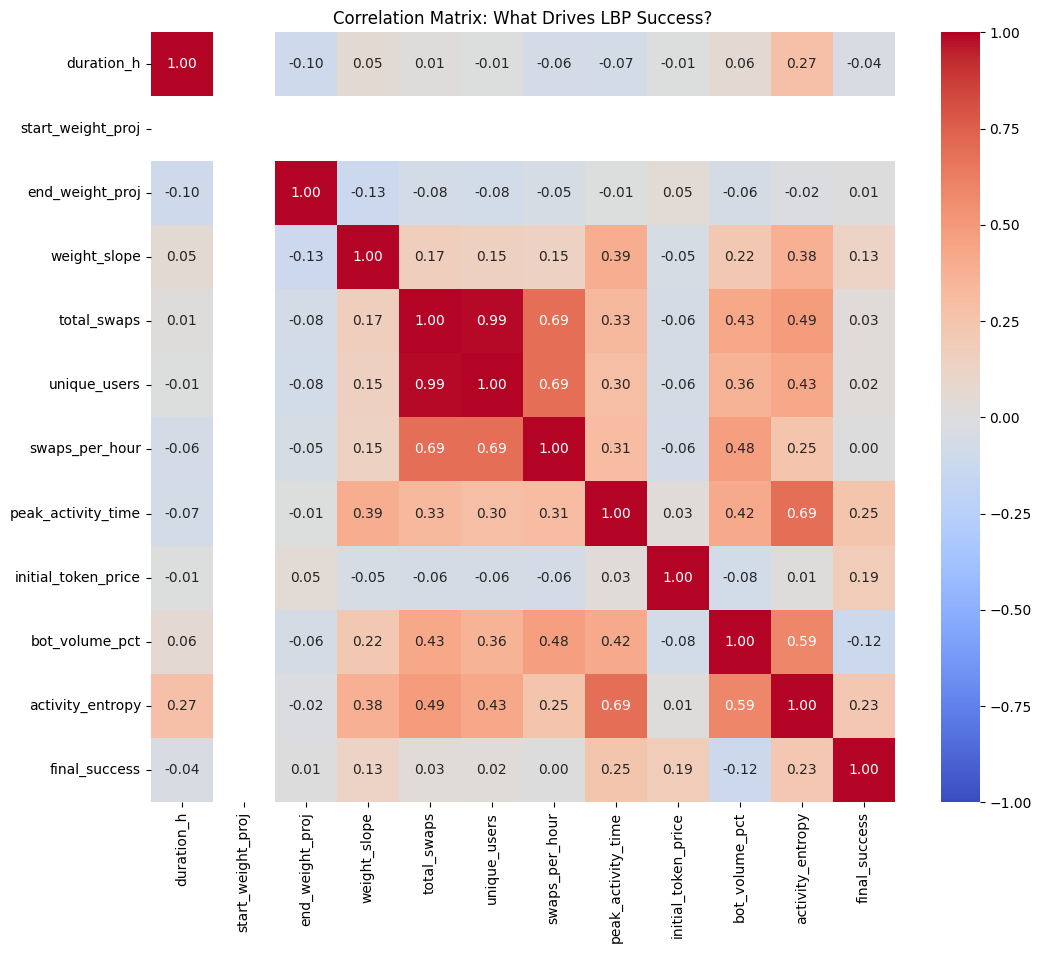

Correlations with 'final_success':
final_success          1.000000
peak_activity_time     0.245509
activity_entropy       0.227289
initial_token_price    0.194490
weight_slope           0.125976
total_swaps            0.031213
unique_users           0.021184
end_weight_proj        0.006967
swaps_per_hour         0.001639
duration_h            -0.035147
bot_volume_pct        -0.119146
start_weight_proj           NaN
Name: final_success, dtype: float64


In [6]:
def plot_correlation_heatmap(df):
    # 1. Select numeric columns only
    # We drop 'pool_id', 'launch_date', etc.
    cols_to_analyze = [
        'duration_h', 'start_weight_proj', 'end_weight_proj', 'weight_slope',
        'total_swaps', 'unique_users', 'swaps_per_hour', 'peak_activity_time',
        'initial_token_price', 'bot_volume_pct', 'activity_entropy',
        'final_success' # The Target
    ]
    
    # Filter for columns that actually exist in your DF
    existing_cols = [c for c in cols_to_analyze if c in df.columns]
    df_corr = df[existing_cols]

    # 2. Calculate Correlation
    corr_matrix = df_corr.corr()

    # 3. Plot Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix, 
        annot=True,     # Show numbers
        fmt=".2f",      # 2 decimal places
        cmap='coolwarm',# Red = Positive, Blue = Negative
        vmin=-1, vmax=1 # Fix scale from -1 to 1
    )
    plt.title('Correlation Matrix: What Drives LBP Success?')
    plt.show()
    
    # 4. Print numerical correlations with the Target
    print("Correlations with 'final_success':")
    print(corr_matrix['final_success'].sort_values(ascending=False))

# Usage
plot_correlation_heatmap(df_labeled)

# Save final CSV

In [18]:
df_labeled.to_csv('FINAL_LBPs_BalancerV1.csv', index=False)